In [6]:
import os 
os.environ["RAY_AIR_NEW_OUTPUT"] = '0'
os.environ.get("RAY_AIR_NEW_OUTPUT", "1") == "0"

True

In [37]:
from monai.metrics import ROCAUCMetric
import torch

auc_metric = ROCAUCMetric()
auc_metric(torch.tensor([0,.2,.3,.1]), torch.tensor([0,0,0,0]))
auc_value = auc_metric.aggregate()
auc_metric.reset()

auc_value

c:\Users\MacRaeDC\AppData\Local\anaconda3\envs\HNC_310\lib\site-packages\monai\metrics\rocauc.py:83: UserWarning: y values can not be all 0, skip AUC computation and return `Nan`.
  warnings.warn(f"y values can not be all {y_unique.item()}, skip AUC computation and return `Nan`.")


nan

In [38]:
from torcheval.metrics import BinaryAUROC
import torch

metric = BinaryAUROC()
metric.reset()
metric.update(torch.tensor([0,.2,.3,.1]), torch.tensor([0,0,0,0]))
metric.compute()

tensor(0.5000, dtype=torch.float64)

In [41]:
from torcheval.metrics.aggregation.auc import AUC
metric2 = AUC(n_tasks=1)
metric2.reset()
metric2.update(torch.tensor([0,.2,.3,.1]), torch.tensor([0,0,0,0]))
metric2.compute()

tensor([0.])

In [71]:
import random
#np.random.choice([1,2,3,4,5], size=5).tolist()
#[ [random.choice([1,2,3,4,5])*3] for x in range(config["num_conv_layers"]) ]

[ [random.choice([1,2,3,4,5])]*3 for x in range(5) ]

[[5, 5, 5], [5, 5, 5], [1, 1, 1], [5, 5, 5], [1, 1, 1]]

In [48]:
import time
from typing import Dict, Optional, Any

import ray
from ray import train, tune
from ray.tune.search import ConcurrencyLimiter
from ray.tune.search.optuna import OptunaSearch
from ray.tune import Trainable

from ray.train.torch import TorchTrainer, get_device
import random
import os

ray.shutdown()
ray.init(configure_logging=False)

def evaluate(width, height, activation, path_ray):
    time.sleep(0.1)
    device  = get_device()
    activation_boost = 10 if activation=="relu" else 0

    # with open(os.getcwd() + f"/artifact_{0}.txt", "w") as f:
    #     f.write("Artifact Data")
    #     print(Trainable().trial_name)

    return (0.1 + width * 100) ** (-1) + height * random.random() + activation_boost


def objective(hp_param_config):
    print("Hello")

    for key in hp_param_config:
        cfg.key = hp_param_config[key]

    train.report({"mean_loss": random.random()})


def trial_str_creator(trial):
    return "{}_{}_123".format(trial.trainable_name, trial.trial_id)


#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
algo = OptunaSearch()
algo = ConcurrencyLimiter(algo, max_concurrent=4)
num_samples = 3

storage_path = "C:/Users/MacRaeDC/ray_results"
exp_name = "play1"

tuner = tune.Tuner(
    objective,
    tune_config=tune.TuneConfig(
        metric="mean_loss",
        mode="min",
        search_alg=algo,
        num_samples=num_samples,
        trial_name_creator=trial_str_creator,
    ),
    run_config=train.RunConfig(
        name=exp_name, storage_path=storage_path),

    param_space=param_space,
)
results = tuner.fit()

(raylet) '\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\DL_NTCP_Multitox'
(raylet) CMD.EXE was started with the above path as the current directory.
(raylet) UNC paths are not supported.  Defaulting to Windows directory.


(objective pid=17116) Hello
(objective pid=17116) Hello
(objective pid=17116) Hello


(raylet) '\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\DL_NTCP_Multitox' [repeated 2x across cluster]
(raylet) CMD.EXE was started with the above path as the current directory. [repeated 2x across cluster]
(raylet) UNC paths are not supported.  Defaulting to Windows directory. [repeated 2x across cluster]


In [32]:

print(full_dir)
dir_list = os.path.splitext(full_dir)


\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\DL_NTCP_Multitox


('\\\\zkh\\appdata\\RTDicom\\Projectline_HNC_modelling\\Users\\Daniel MacRae\\DL_NTCP_Multitox',
 '')

In [36]:
import os
full_dir = os.getcwd()
path = os.path.normpath(full_dir)
path.split(os.sep)

['',
 '',
 'zkh',
 'appdata',
 'RTDicom',
 'Projectline_HNC_modelling',
 'Users',
 'Daniel MacRae',
 'DL_NTCP_Multitox']

In [14]:
from config import exp_root_dir
#exp_root_dir = os.path.join(root_path, 'experiments', 'HP_1')
# if not hyperparameter_tuning_mode:
#     create_folder_if_not_exists(exp_root_dir)
# exp_name = datetime.now().strftime("%Y%m%d_%H%M%S")
# exp_dir = os.path.join(exp_root_dir, exp_name)


//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Multitox\experiments
HP_1


In [31]:
from ray import tune

# Load the result grid from the previous Ray Tune run
experiment_path = "C:/Users/MacRaeDC/ray_results/play1"


restored_tuner = tune.Tuner.restore(experiment_path, trainable=objective)
result_grid = restored_tuner.get_results()

In [32]:
(result_grid.get_dataframe())

,iterations,mean_loss,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,pid,hostname,node_ip,time_since_restore,iterations_since_restore,config/steps,config/width,config/height,config/activation,logdir
0,99,22.064203,1707299311,None,False,100,7bbca657,2024-02-07_10-48-31,0.114341,10.778521,24384,23-006-1660,127.0.0.1,10.778521,100,100,19.305416,37.030476,relu,7bbca657
1,99,8.930472,1707299317,None,False,100,dba9828b,2024-02-07_10-48-37,0.107020,10.776298,21996,23-006-1660,127.0.0.1,10.776298,100,100,9.831452,-9.889761,relu,dba9828b
2,99,5.042460,1707299328,None,False,100,5b2ed741,2024-02-07_10-48-48,0.116273,10.843090,21996,23-006-1660,127.0.0.1,10.843090,100,100,5.163446,7.806430,tanh,5b2ed741
3,99,42.435134,1707299322,None,False,100,fb3be9a2,2024-02-07_10-48-42,0.108301,10.728814,24384,23-006-1660,127.0.0.1,10.728814,100,100,7.674571,45.894371,tanh,fb3be9a2
4,99,18.583748,1707299333,None,False,100,4a3bf6e8,2024-02-07_10-48-53,0.101732,10.896468,24384,23-006-1660,127.0.0.1,10.896468,100,100,0.311766,87.674824,tanh,4a3bf6e8
5,99,-0.926381,1707299339,None,False,100,8c7f0b96,2024-02-07_10-48-59,0.101894,10.876549,21760,23-006-1660,127.0.0.1,10.876549,100,100,13.131140,-5.509345,tanh,8c7f0b96
6,99,-71.167614,1707299344,None,False,100,33e9ca1d,2024-02-07_10-49-04,0.113732,10.741668,24384,23-006-1660,127.0.0.1,10.741668,100,100,14.652364,-90.272501,relu,33e9ca1d
7,99,9.159039,1707299350,None,False,100,9fc12cb8,2024-02-07_10-49-10,0.106393,10.943367,21760,23-006-1660,127.0.0.1,10.943367,100,100,17.702796,-1.272911,relu,9fc12cb8
8,99,-34.410698,1707299339,None,False,100,beb2a921,2024-02-07_10-48-59,0.106427,10.849918,21996,23-006-1660,127.0.0.1,10.849918,100,100,6.389960,-73.083380,tanh,beb2a921
9,99,20.957517,1707299350,None,False,100,356349d0,2024-02-07_10-49-10,0.114528,10.824151,21996,23-006-1660,127.0.0.1,10.824151,100,100,15.786517,11.021572,relu,356349d0


In [33]:
dfs = {result.path: result.metrics_dataframe for result in results}
[d.mean_loss.plot() for d in dfs.values()]

[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >]

In [34]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for d in dfs.values():
    ax = d.mean_loss.plot(ax=ax, legend=False)


Text(0, 0.5, 'Mean Test Accuracy')

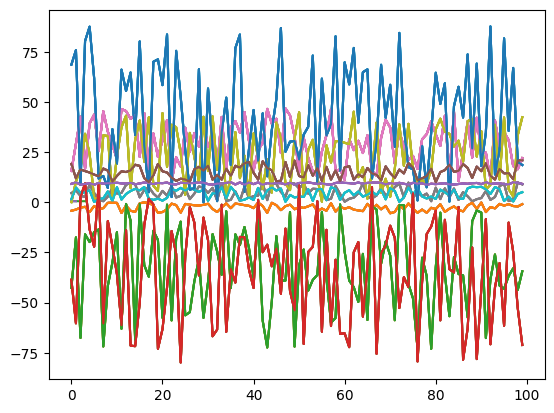

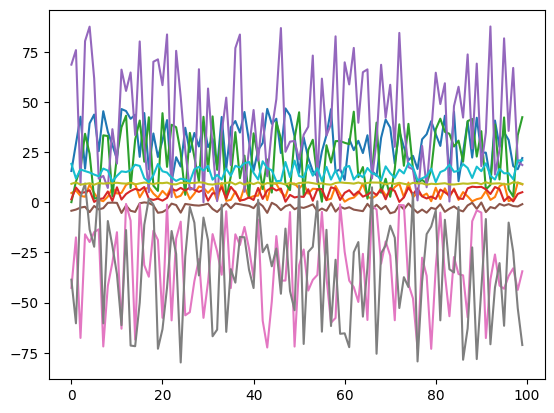

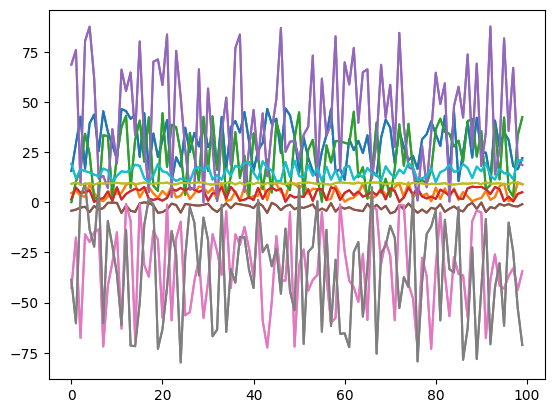

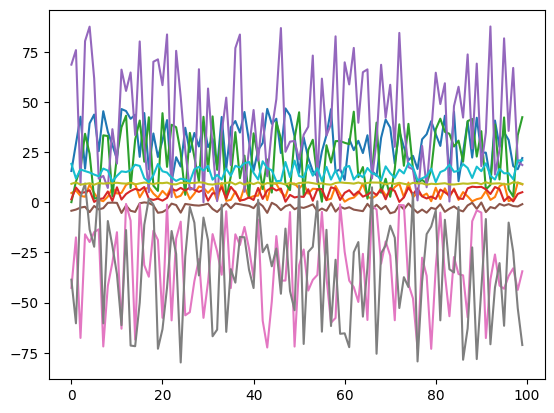

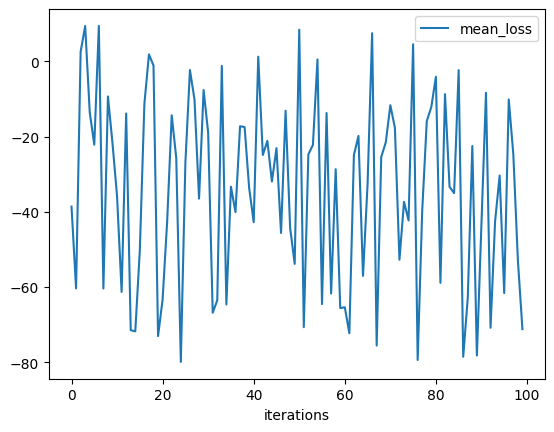

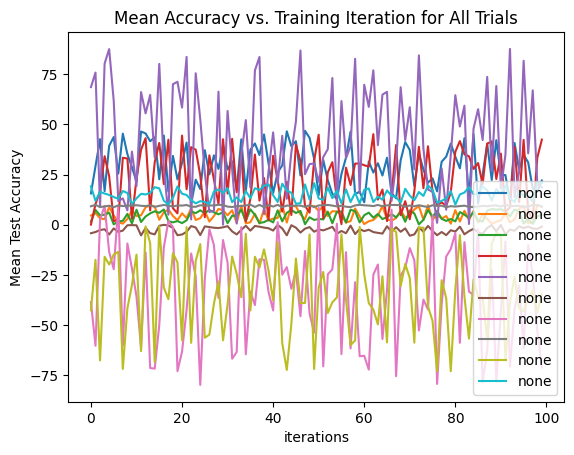

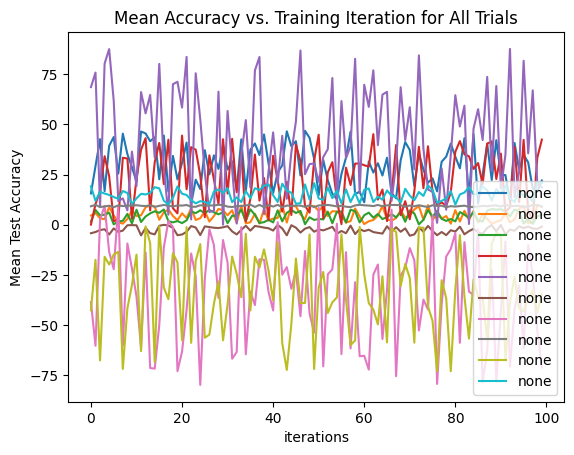

In [44]:
%matplotlib inline
ax = None
for result in result_grid:
    label = "none" #f"lr={result.config['lr']:.3f}, momentum={result.config['momentum']}"
    if ax is None:
        ax = result.metrics_dataframe.plot("iterations", "mean_loss", label=label)
    else:
        result.metrics_dataframe.plot("iterations", "mean_loss", ax=ax, label=label)
ax.set_title("Mean Accuracy vs. Training Iteration for All Trials")
ax.set_ylabel("Mean Test Accuracy")


In [43]:
result.metrics_dataframe.mean_loss

0     19.156093
1     11.917868
2     16.381447
3     15.565460
4     14.846745
        ...    
95    14.455794
96    14.504455
97    11.548165
98    20.797769
99    20.957517
Name: mean_loss, Length: 100, dtype: float64

In [35]:
dfs

{'C:/Users/MacRaeDC/ray_results/play1/objective_7bbca657_123_1_activation=relu,height=37.0305,steps=100,width=19.3054_2024-02-07_10-48-14':     iterations  mean_loss   timestamp checkpoint_dir_name   done  \
 0            0  15.606381  1707299300                None  False   
 1            1  29.245836  1707299300                None  False   
 2            2  42.667702  1707299300                None  False   
 3            3  16.758848  1707299300                None  False   
 4            4  39.358071  1707299301                None  False   
 ..         ...        ...         ...                 ...    ...   
 95          95  34.898162  1707299311                None  False   
 96          96  31.064581  1707299311                None  False   
 97          97  18.050888  1707299311                None  False   
 98          98  16.483144  1707299311                None  False   
 99          99  22.064203  1707299311                None  False   
 
     training_iteration  trial_

In [1]:
import numpy as np
count = np.array([10, 100])
summ = count.sum()
weights = count/summ
weights = 1 /weights
summ = weights.sum()
weights = weights/summ

print(weights)


[0.90909091 0.09090909]


In [29]:
results.get_best_result("mean_loss", mode="min")

Result(
  metrics={'iterations': 99, 'mean_loss': -71.1676143798012},
  path='C:/Users/MacRaeDC/ray_results/play1/objective_33e9ca1d_123_8_activation=relu,height=-90.2725,steps=100,width=14.6524_2024-02-07_10-48-48',
  filesystem='local',
  checkpoint=None
)

In [45]:
df = results.get_dataframe()
df

,iterations,mean_loss,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,pid,hostname,node_ip,time_since_restore,iterations_since_restore,config/steps,config/width,config/height,config/activation,logdir
0,99,-1.265018,1707210395,None,False,100,6317eafb,2024-02-06_10-06-35,0.100484,10.099920,26156,23-006-1660,127.0.0.1,10.099920,100,100,6.041221,-14.294697,tanh,6317eafb
1,99,-9.190253,1707210400,None,False,100,2a4b269c,2024-02-06_10-06-40,0.100527,10.093188,24324,23-006-1660,127.0.0.1,10.093188,100,100,12.920710,-92.678238,tanh,2a4b269c
2,99,8.028951,1707210405,None,False,100,c09ec452,2024-02-06_10-06-45,0.101999,10.098230,26156,23-006-1660,127.0.0.1,10.098230,100,100,19.459833,79.773116,tanh,c09ec452
3,99,-4.419254,1707210410,None,False,100,f82cd293,2024-02-06_10-06-50,0.101004,10.101161,2876,23-006-1660,127.0.0.1,10.101161,100,100,16.484815,-44.801557,tanh,f82cd293
4,99,3.564212,1707210410,None,False,100,efc22da9,2024-02-06_10-06-50,0.101210,10.094946,24324,23-006-1660,127.0.0.1,10.094946,100,100,4.442235,33.418822,tanh,efc22da9
5,99,1.761307,1707210415,None,False,100,0180463e,2024-02-06_10-06-55,0.100999,10.107142,26156,23-006-1660,127.0.0.1,10.107142,100,100,16.438600,17.002359,tanh,0180463e
6,99,10.858294,1707210421,None,False,100,3c017b42,2024-02-06_10-07-01,0.100704,10.098883,2876,23-006-1660,127.0.0.1,10.098883,100,100,13.126803,7.819322,relu,3c017b42
7,99,4.640244,1707210421,None,False,100,a769f55c,2024-02-06_10-07-01,0.101098,10.094751,24324,23-006-1660,127.0.0.1,10.094751,100,100,16.670598,-54.199826,relu,a769f55c
8,99,-1.818661,1707210426,None,False,100,e4d7b560,2024-02-06_10-07-06,0.102367,10.135380,26156,23-006-1660,127.0.0.1,10.135380,100,100,1.684955,-23.842382,tanh,e4d7b560
9,99,7.989504,1707210431,None,False,100,e7e2849d,2024-02-06_10-07-11,0.101296,10.139907,2876,23-006-1660,127.0.0.1,10.139907,100,100,2.504968,76.018949,tanh,e7e2849d


In [47]:
dfs = {result.logdir: result.metrics_dataframe for result in results}
[d.mean_accuracy.plot() for d in dfs.values()]



AttributeError: 'Result' object has no attribute 'logdir'